# AugMix + CE + JSD Consistency Training

## 1. Imports

In [1]:
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm import tqdm

from cnn_experiments.cnn import StandardCNN
from src.dataset._balance_class_subset import BalancedClassSubset
from archive.dataset.tiny_imagenet_dataset import TinyImageNetLoader, show_image, get_tiny_imagenet_class_names, means, stds

print("PyTorch:", torch.__version__)

PyTorch: 2.13.0


## 2. Configuration

In [2]:
SEED = 42

NUM_CLASSES = 200
SELECTED_CLASSES = list(range(NUM_CLASSES))
TRAIN_IMAGES_PER_CLASS = 500
VAL_IMAGES_PER_CLASS = 50

BATCH_SIZE = 32
NUM_WORKERS = 0
EPOCHS = 90

MAX_LR = 0.06
SGD_WEIGHT_DECAY = 5e-4
LABEL_SMOOTHING = 0.10

FEATURE_DROPOUT = 0.40
BLOCK3_DROPOUT = 0.15
BLOCK4_DROPOUT = 0.25

# AugMix + consistency settings
AUGMIX_SEVERITY = 3
AUGMIX_WIDTH = 3
AUGMIX_DEPTH = -1
AUGMIX_ALPHA = 1.0
JSD_WEIGHT = 12.0

EARLY_STOPPING_PATIENCE = 30

SAVE_PATH = f"ce_aug_mix_jsd_12_{NUM_CLASSES}.pth"
TINY_ROOT = "../../data/tiny_imagenet"


## 3. Reproducibility and Device

In [3]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Device:", DEVICE)

Device: mps


## 4. AugMix + JSD Data Preparation

In [4]:
def convert_to_rgb(image):
    return image.convert("RGB")


# Shared spatial transform:
# clean, aug1 and aug2 use the SAME crop and horizontal flip.
base_train_transform = transforms.Compose([
    transforms.Lambda(convert_to_rgb),
    transforms.RandomCrop(64, padding=4, padding_mode="reflect"),
    transforms.RandomHorizontalFlip(p=0.5)
])


# Independent AugMix perturbation used for aug1 and aug2.
augmix_transform = transforms.AugMix(
    severity=AUGMIX_SEVERITY,
    mixture_width=AUGMIX_WIDTH,
    chain_depth=AUGMIX_DEPTH,
    alpha=AUGMIX_ALPHA
)


# Applied after clean/AugMix view creation.
final_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])


# Clean deterministic evaluation transform.
test_transform = transforms.Compose([
    transforms.Lambda(convert_to_rgb),
    transforms.ToTensor(),
    transforms.Normalize(mean=means, std=stds)
])


# Raw training transform: wrapper below creates all three views.
raw_train_transform = transforms.Lambda(convert_to_rgb)


class AugMixJSDDataset(Dataset):
    """Return (clean, aug1, aug2), label for full AugMix consistency training."""

    def __init__(self, dataset, base_transform, augmix_transform, final_transform):
        self.dataset = dataset
        self.base_transform = base_transform
        self.augmix_transform = augmix_transform
        self.final_transform = final_transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, label = self.dataset[index]

        # Apply crop + horizontal flip once.
        image = self.base_transform(image)

        # Clean view.
        clean = self.final_transform(image)

        # Two independently AugMixed views.
        aug1 = self.final_transform(self.augmix_transform(image))
        aug2 = self.final_transform(self.augmix_transform(image))

        return (clean, aug1, aug2), label


train_dataset, val_dataset, _, _ = TinyImageNetLoader(
    seed=SEED,
    root=Path(TINY_ROOT),
    train_transform=raw_train_transform,
    test_transform=test_transform
).load()
train_eval_dataset, _, _, _ = TinyImageNetLoader(
    seed=SEED,
    root=Path(TINY_ROOT),
    train_transform=test_transform,
    test_transform=test_transform
).load()


FULL_CLASS_NAMES = get_tiny_imagenet_class_names(train_dataset, TINY_ROOT)
CLASS_NAMES = [FULL_CLASS_NAMES[class_id] for class_id in SELECTED_CLASSES]

print("Full train dataset:", len(train_dataset))
print("Full validation dataset:", len(val_dataset))
print("Full clean train-eval dataset:", len(train_eval_dataset))

Full train dataset: 100000
Full validation dataset: 10000
Full clean train-eval dataset: 100000


## 5. Select the Same 10 Classes

In [5]:
train_subset = BalancedClassSubset(
    train_dataset,
    SELECTED_CLASSES,
    TRAIN_IMAGES_PER_CLASS,
    seed=SEED
)

train_eval_subset = BalancedClassSubset(
    train_eval_dataset,
    SELECTED_CLASSES,
    TRAIN_IMAGES_PER_CLASS,
    seed=SEED
)

val_subset = BalancedClassSubset(
    val_dataset,
    SELECTED_CLASSES,
    VAL_IMAGES_PER_CLASS,
    seed=SEED + 1
)

print("Same selected training samples:", train_subset.samples == train_eval_subset.samples)
print("Selected classes:", len(SELECTED_CLASSES))
print("Training images:", len(train_subset))
print("Clean train-eval images:", len(train_eval_subset))
print("Validation images:", len(val_subset))

augmix_train_subset = AugMixJSDDataset(
    train_subset,
    base_transform=base_train_transform,
    augmix_transform=augmix_transform,
    final_transform=final_transform
)

print("AugMix-JSD training images:", len(augmix_train_subset))

Same selected training samples: True
Selected classes: 200
Training images: 100000
Clean train-eval images: 100000
Validation images: 10000
AugMix-JSD training images: 100000


## 6. DataLoaders

In [6]:
generator = torch.Generator()
generator.manual_seed(SEED)
persistent_workers = NUM_WORKERS > 0

train_loader = DataLoader(
    augmix_train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=generator,
    num_workers=NUM_WORKERS,
    persistent_workers=persistent_workers
)

train_eval_loader = DataLoader(
    train_eval_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    persistent_workers=persistent_workers
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    persistent_workers=persistent_workers
)

print("Training batches:", len(train_loader))
print("Clean train-eval batches:", len(train_eval_loader))
print("Validation batches:", len(val_loader))

Training batches: 3125
Clean train-eval batches: 3125
Validation batches: 313


## 7. Show Clean, AugMix and Validation Images

In [7]:
NUM_SHOW = 10

train_iter = iter(train_loader)
val_iter = iter(val_loader)

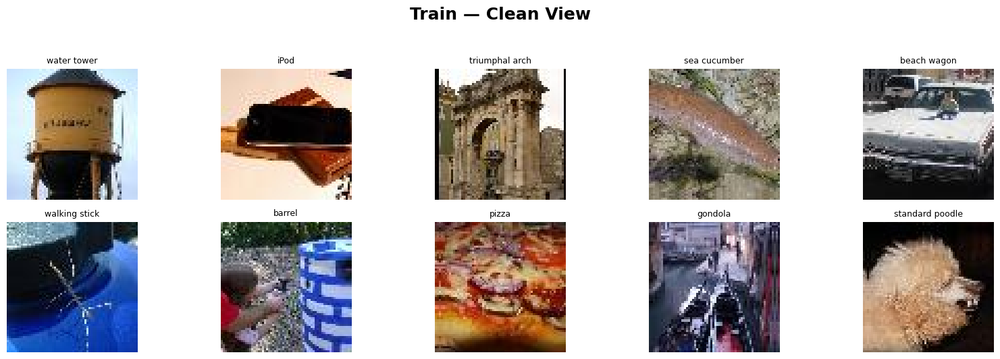

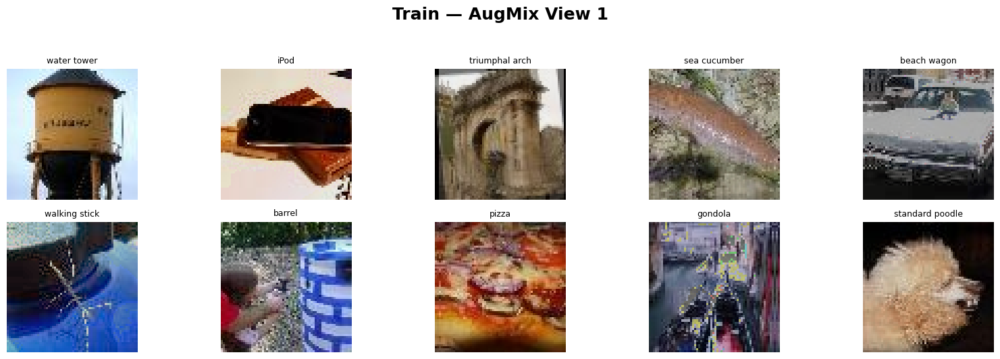

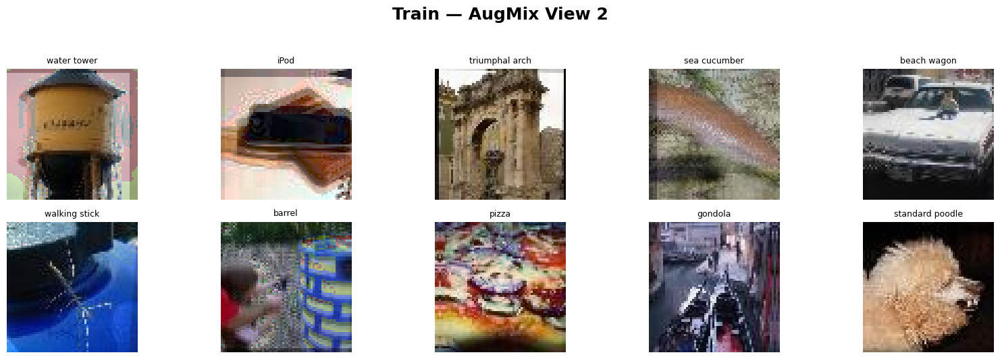

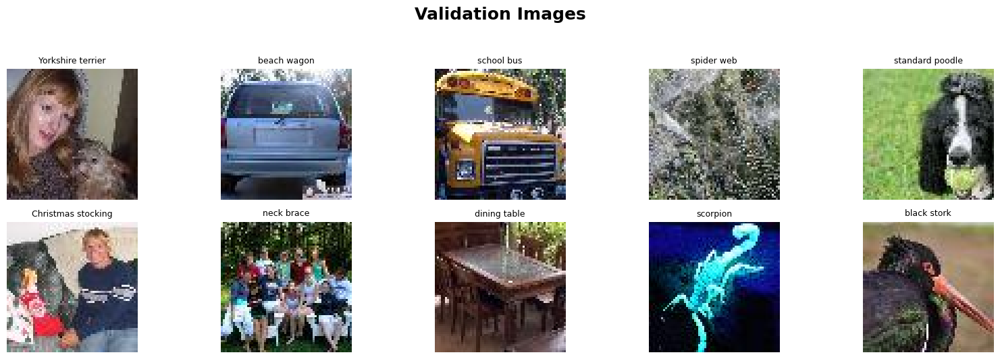

In [8]:
(views, labels) = next(train_iter)
clean_images, aug1_images, aug2_images = views

show_image(clean_images, labels, NUM_SHOW, CLASS_NAMES, name="Train — Clean View")
show_image(aug1_images, labels, NUM_SHOW, CLASS_NAMES, name="Train — AugMix View 1")
show_image(aug2_images, labels, NUM_SHOW, CLASS_NAMES, name="Train — AugMix View 2")

images, labels = next(val_iter)
show_image(images, labels, NUM_SHOW, CLASS_NAMES, name="Validation Images")

## 8. Create Model

In [9]:
model = StandardCNN(num_classes=NUM_CLASSES, feature_dropout=FEATURE_DROPOUT, block3_dropout=BLOCK3_DROPOUT,
                    block4_dropout=BLOCK4_DROPOUT).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable parameters (M): {trainable_params / 1e6:.3f}M")

x = torch.randn(2, 3, 64, 64, device=DEVICE)

model.eval()
with torch.no_grad():
    r1 = model.level1(x)
    r2 = model.level2(r1)
    r3 = model.level3(r2)
    r4 = model.level4(r3)
    features = torch.flatten(model.global_pool(r4), 1)
    logits = model(x)

print("Input:", x.shape)
print("r1:", r1.shape)
print("r2:", r2.shape)
print("r3:", r3.shape)
print("r4:", r4.shape)
print("Features:", features.shape)
print("Logits:", logits.shape)

model.train()

Total parameters: 2,714,648
Trainable parameters: 2,714,648
Trainable parameters (M): 2.715M
Input: torch.Size([2, 3, 64, 64])
r1: torch.Size([2, 48, 32, 32])
r2: torch.Size([2, 96, 16, 16])
r3: torch.Size([2, 192, 8, 8])
r4: torch.Size([2, 384, 4, 4])
Features: torch.Size([2, 384])
Logits: torch.Size([2, 200])


StandardCNN(
  (level1): Sequential(
    (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (level2): Sequential(
    (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplac

## 9. Loss, Optimizer and OneCycleLR

In [10]:
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=MAX_LR,
    momentum=0.9,
    weight_decay=SGD_WEIGHT_DECAY,
    nesterov=True
)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=MAX_LR,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.10,
    anneal_strategy="cos",
    div_factor=10.0,
    final_div_factor=10.0
)

print("Loss: CrossEntropyLoss + AugMix JSD consistency")
print("Label smoothing:", LABEL_SMOOTHING)
print("JSD weight:", JSD_WEIGHT)
print("Optimizer: SGD + Nesterov")
print("Weight decay:", SGD_WEIGHT_DECAY)
print("OneCycle max LR:", MAX_LR)
print("Initial scheduled LR:", optimizer.param_groups[0]["lr"])
print("Epochs:", EPOCHS)
print("Steps per epoch:", len(train_loader))

Loss: CrossEntropyLoss + AugMix JSD consistency
Label smoothing: 0.1
JSD weight: 12.0
Optimizer: SGD + Nesterov
Weight decay: 0.0005
OneCycle max LR: 0.06
Initial scheduled LR: 0.005999999999999998
Epochs: 90
Steps per epoch: 3125


## 10. AugMix + CE + JSD Training Pass

In [11]:
def augmix_jsd_loss(logits_clean, logits_aug1, logits_aug2):
    p_clean = F.softmax(logits_clean, dim=1)
    p_aug1 = F.softmax(logits_aug1, dim=1)
    p_aug2 = F.softmax(logits_aug2, dim=1)

    # Mixture distribution M = (Pclean + Paug1 + Paug2) / 3
    p_mixture = (p_clean + p_aug1 + p_aug2) / 3.0
    log_mixture = torch.log(p_mixture.clamp_min(1e-7))

    # JSD = average KL(P_i || M)
    jsd = (
        F.kl_div(log_mixture, p_clean, reduction="batchmean")
        + F.kl_div(log_mixture, p_aug1, reduction="batchmean")
        + F.kl_div(log_mixture, p_aug2, reduction="batchmean")
    ) / 3.0

    return jsd


def train_one_epoch(model, train_loader, optimizer, criterion, scheduler, device):
    model.train()

    running_total_loss = 0.0
    running_ce_loss = 0.0
    running_jsd_loss = 0.0

    correct = 0
    total = 0

    for views, labels in train_loader:
        clean, aug1, aug2 = views

        clean = clean.to(device)
        aug1 = aug1.to(device)
        aug2 = aug2.to(device)
        labels = labels.to(device)

        optimizer.zero_grad(set_to_none=True)

        batch_size = labels.size(0)

        # One forward call for all three views.
        all_images = torch.cat([clean, aug1, aug2], dim=0)
        all_logits = model(all_images)

        logits_clean, logits_aug1, logits_aug2 = torch.split(
            all_logits,
            batch_size,
            dim=0
        )

        # CE teaches the correct class.
        ce_loss = criterion(logits_clean, labels)

        # JSD teaches prediction consistency across the three views.
        jsd_loss = augmix_jsd_loss(
            logits_clean,
            logits_aug1,
            logits_aug2
        )

        total_loss = ce_loss + JSD_WEIGHT * jsd_loss

        total_loss.backward()
        optimizer.step()
        scheduler.step()

        predictions = logits_clean.argmax(dim=1)

        running_total_loss += total_loss.item() * batch_size
        running_ce_loss += ce_loss.item() * batch_size
        running_jsd_loss += jsd_loss.item() * batch_size

        correct += (predictions == labels).sum().item()
        total += batch_size

    return {
        "loss": running_total_loss / total,
        "ce_loss": running_ce_loss / total,
        "jsd_loss": running_jsd_loss / total,
        "accuracy": 100.0 * correct / total
    }

## 11. Evaluation Pass

In [12]:
@torch.inference_mode()
def evaluate(model, data_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_predictions = []

    for images, labels in data_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)
        predictions = outputs.argmax(dim=1)
        batch_size = labels.size(0)

        running_loss += loss.item() * batch_size
        correct += (predictions == labels).sum().item()
        total += batch_size
        all_labels.append(labels.cpu())
        all_predictions.append(predictions.cpu())

    return {"loss": running_loss / total, "accuracy": 100.0 * correct / total, "labels": torch.cat(all_labels),
            "predictions": torch.cat(all_predictions)}

# Till here

## 12. Train Model

In [13]:
history = {
    "train_loss": [],
    "train_ce_loss": [],
    "train_jsd_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "train_eval_loss": [],
    "train_eval_accuracy": [],
    "train_val_gap": [],
    "clean_train_eval_val_gap": [],
    "learning_rate": []
}

best_val_accuracy = 0.0
best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

for epoch in tqdm(range(1, EPOCHS + 1)):
    # PHASE 1: AugMix + CE + JSD training.
    train_result = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        scheduler,
        DEVICE
    )

    # PHASE 2: clean validation.
    val_result = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # PHASE 3: clean evaluation of the same selected training images.
    train_eval_result = evaluate(
        model,
        train_eval_loader,
        criterion,
        DEVICE
    )

    current_lr = optimizer.param_groups[0]["lr"]

    train_val_gap = (
        train_result["accuracy"]
        - val_result["accuracy"]
    )

    clean_train_eval_val_gap = (
        train_eval_result["accuracy"]
        - val_result["accuracy"]
    )

    history["train_loss"].append(train_result["loss"])
    history["train_ce_loss"].append(train_result["ce_loss"])
    history["train_jsd_loss"].append(train_result["jsd_loss"])
    history["train_accuracy"].append(train_result["accuracy"])

    history["val_loss"].append(val_result["loss"])
    history["val_accuracy"].append(val_result["accuracy"])

    history["train_eval_loss"].append(train_eval_result["loss"])
    history["train_eval_accuracy"].append(train_eval_result["accuracy"])

    history["train_val_gap"].append(train_val_gap)
    history["clean_train_eval_val_gap"].append(clean_train_eval_val_gap)
    history["learning_rate"].append(current_lr)

    improved = (
        val_result["accuracy"] > best_val_accuracy
        or (
            val_result["accuracy"] == best_val_accuracy
            and val_result["loss"] < best_val_loss
        )
    )

    if improved:
        best_val_accuracy = val_result["accuracy"]
        best_val_loss = val_result["loss"]
        best_epoch = epoch
        epochs_without_improvement = 0

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),

            "train_loss": train_result["loss"],
            "train_ce_loss": train_result["ce_loss"],
            "train_jsd_loss": train_result["jsd_loss"],
            "train_accuracy": train_result["accuracy"],

            "val_loss": val_result["loss"],
            "val_accuracy": val_result["accuracy"],

            "train_eval_loss": train_eval_result["loss"],
            "train_eval_accuracy": train_eval_result["accuracy"],

            "train_val_gap": train_val_gap,
            "clean_train_eval_val_gap": clean_train_eval_val_gap,
            "learning_rate": current_lr,

            "num_classes": NUM_CLASSES,
            "label_smoothing": LABEL_SMOOTHING,
            "max_lr": MAX_LR,
            "weight_decay": SGD_WEIGHT_DECAY,

            "architecture": "48-96-192-384",
            "training_method": "AugMix + CE + JSD",

            "augmix_severity": AUGMIX_SEVERITY,
            "augmix_width": AUGMIX_WIDTH,
            "augmix_depth": AUGMIX_DEPTH,
            "augmix_alpha": AUGMIX_ALPHA,
            "jsd_weight": JSD_WEIGHT
        }

        torch.save(checkpoint, SAVE_PATH)

        print(
            f"  -> Best model saved | "
            f"Epoch: {epoch} | "
            f"Val Acc: {val_result['accuracy']:.2f}% | "
            f"Val Loss: {val_result['loss']:.4f}"
        )
    else:
        epochs_without_improvement += 1

    print(f"Epoch [{epoch:03d}/{EPOCHS:03d}] | LR: {current_lr:.6f}")

    print(
        f"Train      -> "
        f"Total: {train_result['loss']:.4f} | "
        f"CE: {train_result['ce_loss']:.4f} | "
        f"JSD: {train_result['jsd_loss']:.4f} | "
        f"Acc: {train_result['accuracy']:.2f}%"
    )

    print(
        f"Validation -> "
        f"Loss: {val_result['loss']:.4f} | "
        f"Acc: {val_result['accuracy']:.2f}%"
    )

    print(f"Train-Val Gap: {train_val_gap:.2f} pp")
    print("Additional:")

    print(
        f"Clean Train Eval -> "
        f"Loss: {train_eval_result['loss']:.4f} | "
        f"Acc: {train_eval_result['accuracy']:.2f}%"
    )

    print(
        f"Clean Train Eval-Val Gap: "
        f"{clean_train_eval_val_gap:.2f} pp"
    )

    print(
        f"Best Val Acc: "
        f"{best_val_accuracy:.2f}% @ Epoch {best_epoch}"
    )

    print("-" * 90)

    if (
        EARLY_STOPPING_PATIENCE is not None
        and epochs_without_improvement >= EARLY_STOPPING_PATIENCE
    ):
        print(
            f"Early stopping at epoch {epoch}. "
            f"No validation improvement for "
            f"{EARLY_STOPPING_PATIENCE} epochs."
        )
        break

print("=" * 90)
print(
    f"Best Epoch: {best_epoch} | "
    f"Best Val Acc: {best_val_accuracy:.2f}% | "
    f"Best Val Loss: {best_val_loss:.6f}"
)
print("Best model saved to:", SAVE_PATH)

  1%|          | 1/90 [18:19<27:10:30, 1099.22s/it]

  -> Best model saved | Epoch: 1 | Val Acc: 7.08% | Val Loss: 4.6771
Epoch [001/090] | LR: 0.007628
Train      -> Total: 5.0600 | CE: 4.9454 | JSD: 0.0096 | Acc: 3.86%
Validation -> Loss: 4.6771 | Acc: 7.08%
Train-Val Gap: -3.22 pp
Additional:
Clean Train Eval -> Loss: 4.6799 | Acc: 7.37%
Clean Train Eval-Val Gap: 0.29 pp
Best Val Acc: 7.08% @ Epoch 1
------------------------------------------------------------------------------------------


  2%|▏         | 2/90 [36:28<26:44:02, 1093.66s/it]

  -> Best model saved | Epoch: 2 | Val Acc: 10.01% | Val Loss: 4.4941
Epoch [002/090] | LR: 0.012317
Train      -> Total: 4.8110 | CE: 4.6168 | JSD: 0.0162 | Acc: 7.85%
Validation -> Loss: 4.4941 | Acc: 10.01%
Train-Val Gap: -2.16 pp
Additional:
Clean Train Eval -> Loss: 4.4836 | Acc: 10.02%
Clean Train Eval-Val Gap: 0.01 pp
Best Val Acc: 10.01% @ Epoch 2
------------------------------------------------------------------------------------------


  3%|▎         | 3/90 [54:35<26:20:53, 1090.27s/it]

...

  -> Best model saved | Epoch: 88 | Val Acc: 47.32% | Val Loss: 3.0521
Epoch [088/090] | LR: 0.000689
Train      -> Total: 3.7114 | CE: 3.1364 | JSD: 0.0479 | Acc: 46.45%
Validation -> Loss: 3.0521 | Acc: 47.32%
Train-Val Gap: -0.87 pp
Additional:
Clean Train Eval -> Loss: 2.9046 | Acc: 51.91%
Clean Train Eval-Val Gap: 4.59 pp
Best Val Acc: 47.32% @ Epoch 88
------------------------------------------------------------------------------------------


 99%|█████████▉| 89/90 [23:14:09<13:39, 819.49s/it]

  -> Best model saved | Epoch: 89 | Val Acc: 47.34% | Val Loss: 3.0121
Epoch [089/090] | LR: 0.000622
Train      -> Total: 3.6940 | CE: 3.1180 | JSD: 0.0480 | Acc: 46.93%
Validation -> Loss: 3.0121 | Acc: 47.34%
Train-Val Gap: -0.41 pp
Additional:
Clean Train Eval -> Loss: 2.8565 | Acc: 52.28%
Clean Train Eval-Val Gap: 4.94 pp
Best Val Acc: 47.34% @ Epoch 89
------------------------------------------------------------------------------------------


100%|██████████| 90/90 [23:25:42<00:00, 937.14s/it]

  -> Best model saved | Epoch: 90 | Val Acc: 47.94% | Val Loss: 3.0281
Epoch [090/090] | LR: 0.000600
Train      -> Total: 3.6849 | CE: 3.1040 | JSD: 0.0484 | Acc: 47.29%
Validation -> Loss: 3.0281 | Acc: 47.94%
Train-Val Gap: -0.65 pp
Additional:
Clean Train Eval -> Loss: 2.8757 | Acc: 52.55%
Clean Train Eval-Val Gap: 4.61 pp
Best Val Acc: 47.94% @ Epoch 90
------------------------------------------------------------------------------------------
Best Epoch: 90 | Best Val Acc: 47.94% | Best Val Loss: 3.028107
Best model saved to: ce_aug_mix_jsd_12_200.pth


In [14]:
# Experiment:
#   StandardCNN 48-96-192-384
#   AugMix + CE + Jensen-Shannon consistency
#
# Total training loss:
#   CE(clean) + 12.0 * JSD(clean, aug1, aug2)

# From here

## 13. Load Best Model and Re-Evaluate

In [15]:
checkpoint = torch.load(
    SAVE_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

best_train_eval_result = evaluate(
    model,
    train_eval_loader,
    criterion,
    DEVICE
)

best_val_result = evaluate(
    model,
    val_loader,
    criterion,
    DEVICE
)

best_train_val_gap = (
    checkpoint["train_accuracy"]
    - best_val_result["accuracy"]
)

best_clean_train_eval_val_gap = (
    best_train_eval_result["accuracy"]
    - best_val_result["accuracy"]
)

print("STANDARD CNN 384 — CE + AUGMIX  + JSD ")
print("=" * 80)

print(f"Best Epoch: {checkpoint['epoch']}")

print(
    f"Train      -> "
    f"Total: {checkpoint['train_loss']:.4f} | "
    f"CE: {checkpoint['train_ce_loss']:.4f} | "
    f"JSD: {checkpoint['train_jsd_loss']:.4f} | "
    f"Acc: {checkpoint['train_accuracy']:.2f}%"
)

print(
    f"Validation -> "
    f"Loss: {best_val_result['loss']:.4f} | "
    f"Acc: {best_val_result['accuracy']:.2f}%"
)

print(f"Train-Val Gap: {best_train_val_gap:.2f} pp")
print("Additional:")

print(
    f"Clean Train Eval -> "
    f"Loss: {best_train_eval_result['loss']:.4f} | "
    f"Acc: {best_train_eval_result['accuracy']:.2f}%"
)

print(
    f"Clean Train Eval-Val Gap: "
    f"{best_clean_train_eval_val_gap:.2f} pp"
)

print("=" * 80)

STANDARD CNN 384 — CE + AUGMIX  + JSD 
Best Epoch: 90
Train      -> Total: 3.6849 | CE: 3.1040 | JSD: 0.0484 | Acc: 47.29%
Validation -> Loss: 3.0281 | Acc: 47.94%
Train-Val Gap: -0.65 pp
Additional:
Clean Train Eval -> Loss: 2.8757 | Acc: 52.55%
Clean Train Eval-Val Gap: 4.61 pp


## 14. t-SNE — Validation Features

In [16]:
# import importlib
# import new_experiment.best_models.cnn as cnn_1
#
# importlib.reload(cnn_1)

model = cnn_1.StandardCNN(num_classes=NUM_CLASSES, feature_dropout=FEATURE_DROPOUT, block3_dropout=BLOCK3_DROPOUT,
                          block4_dropout=BLOCK4_DROPOUT).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Trainable parameters (M): {trainable_params / 1e6:.3f}M")

x = torch.randn(2, 3, 64, 64, device=DEVICE)

model.eval()
with torch.no_grad():
    r1 = model.level1(x)
    r2 = model.level2(r1)
    r3 = model.level3(r2)
    r4 = model.level4(r3)
    features = torch.flatten(model.global_pool(r4), 1)
    logits = model(x)

print("Input:", x.shape)
print("r1:", r1.shape)
print("r2:", r2.shape)
print("r3:", r3.shape)
print("r4:", r4.shape)
print("Features:", features.shape)
print("Logits:", logits.shape)

Total parameters: 2,714,648
Trainable parameters: 2,714,648
Trainable parameters (M): 2.715M
Input: torch.Size([2, 3, 64, 64])
r1: torch.Size([2, 48, 32, 32])
r2: torch.Size([2, 96, 16, 16])
r3: torch.Size([2, 192, 8, 8])
r4: torch.Size([2, 384, 4, 4])
Features: torch.Size([2, 384])
Logits: torch.Size([2, 200])


In [17]:
checkpoint = torch.load(SAVE_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()

StandardCNN(
  (level1): Sequential(
    (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (level2): Sequential(
    (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(96, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplac

Feature shape: (10000, 384)
Label shape: (10000,)
2D feature shape: (10000, 2)


/var/folders/37/53h4p6t90b1g004cj5wzj8g40000gn/T/ipykernel_36813/2277967487.py:68: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


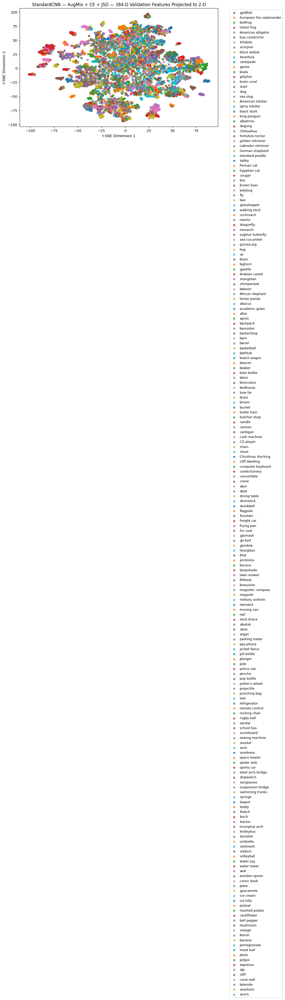

In [18]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import torch


@torch.inference_mode()
def extract_features(model, data_loader, device):
    model.eval()

    all_features = []
    all_labels = []

    for images, labels in data_loader:
        images = images.to(device)

        result = model(images, return_features=True)

        features = result["features"]

        all_features.append(features.cpu())
        all_labels.append(labels.cpu())

    features = torch.cat(all_features, dim=0).numpy()
    labels = torch.cat(all_labels, dim=0).numpy()

    return features, labels


val_features, val_labels = extract_features(
    model,
    val_loader,
    DEVICE
)

print("Feature shape:", val_features.shape)
print("Label shape:", val_labels.shape)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1500,
    random_state=42
)

features_2d = tsne.fit_transform(val_features)

print("2D feature shape:", features_2d.shape)

plt.figure(figsize=(10, 6))

for class_id in range(NUM_CLASSES):
    mask = val_labels == class_id

    plt.scatter(
        features_2d[mask, 0],
        features_2d[mask, 1],
        s=25,
        alpha=0.70,
        label=CLASS_NAMES[class_id]
    )

plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("StandardCNN — AugMix + CE + JSD — 384-D Validation Features Projected to 2-D")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

# Interactive 3D t-SNE

In [19]:
from sklearn.manifold import TSNE
import pandas as pd
import plotly.express as px
from IPython.display import HTML, display

tsne_3d = TSNE(n_components=3, perplexity=30, learning_rate="auto", init="pca", max_iter=1500, random_state=42)
features_3d = tsne_3d.fit_transform(val_features)

print("3D feature shape:", features_3d.shape)

tsne_df = pd.DataFrame({
    "Dim1": features_3d[:, 0],
    "Dim2": features_3d[:, 1],
    "Dim3": features_3d[:, 2],
    "Class": [CLASS_NAMES[label] for label in val_labels]
})

fig = px.scatter_3d(
    tsne_df,
    x="Dim1",
    y="Dim2",
    z="Dim3",
    color="Class",
    opacity=0.75,
    title="StandardCNN — AugMix + CE + JSD — 256-D Validation Features Projected to 3-D"
)

fig.update_traces(marker=dict(size=4))

fig.update_layout(
    width=720,
    height=480,
    scene=dict(
        xaxis_title="t-SNE Dimension 1",
        yaxis_title="t-SNE Dimension 2",
        zaxis_title="t-SNE Dimension 3"
    )
)

display(HTML(fig.to_html(include_plotlyjs=True, full_html=False)))

3D feature shape: (10000, 3)


In [20]:
import numpy as np


def calculate_feature_separation(features, labels, num_classes):
    class_centers = []
    intra_distances = []

    # ---------------------------------------------------------
    # 1. Class centers + intra-class distances
    # ---------------------------------------------------------
    for class_id in range(num_classes):
        class_features = features[labels == class_id]

        center = class_features.mean(axis=0)
        class_centers.append(center)

        distances = np.linalg.norm(
            class_features - center,
            axis=1
        )

        intra_distances.extend(distances)

    class_centers = np.stack(class_centers)

    mean_intra_distance = np.mean(intra_distances)

    # ---------------------------------------------------------
    # 2. Inter-class centroid distances
    # ---------------------------------------------------------
    inter_distances = []

    for i in range(num_classes):
        for j in range(i + 1, num_classes):
            distance = np.linalg.norm(
                class_centers[i] - class_centers[j]
            )

            inter_distances.append(distance)

    mean_inter_distance = np.mean(inter_distances)

    # ---------------------------------------------------------
    # 3. Separation ratio
    # ---------------------------------------------------------
    separation_ratio = (
            mean_inter_distance / mean_intra_distance
    )

    return {
        "mean_intra_distance": mean_intra_distance,
        "mean_inter_distance": mean_inter_distance,
        "separation_ratio": separation_ratio
    }


augmix_jsd_separation = calculate_feature_separation(
    val_features,
    val_labels,
    NUM_CLASSES
)

print("FEATURE SEPARATION — AugMix + CE + JSD")
print("=" * 60)
print(
    f"Mean Intra-Class Distance : "
    f"{augmix_jsd_separation['mean_intra_distance']:.6f}"
)
print(
    f"Mean Inter-Class Distance : "
    f"{augmix_jsd_separation['mean_inter_distance']:.6f}"
)
print(
    f"Inter / Intra Ratio       : "
    f"{augmix_jsd_separation['separation_ratio']:.6f}"
)

FEATURE SEPARATION — AugMix + CE + JSD
Mean Intra-Class Distance : 4.055682
Mean Inter-Class Distance : 6.125686
Inter / Intra Ratio       : 1.510396


## Feature Separation Comparison with 10-Class Baselines

In [21]:
comparison_df = pd.DataFrame([
    {
        "Experiment": "Original CE",
        "Best Val (%)": 78.60,
        "Mean Intra": 1.457860,
        "Mean Inter": 2.414436,
        "Inter/Intra Ratio": 1.656150
    },
    {
        "Experiment": "AugMix + CE",
        "Best Val (%)": 77.00,
        "Mean Intra": 1.466356,
        "Mean Inter": 2.327797,
        "Inter/Intra Ratio": 1.587471
    },
    {
        "Experiment": "AugMix + CE + JSD",
        "Best Val (%)": best_val_result["accuracy"],
        "Mean Intra": augmix_jsd_separation["mean_intra_distance"],
        "Mean Inter": augmix_jsd_separation["mean_inter_distance"],
        "Inter/Intra Ratio": augmix_jsd_separation["separation_ratio"]
    }
])

display(comparison_df)

,Experiment,Best Val (%),Mean Intra,Mean Inter,Inter/Intra Ratio
0,Original CE,78.60,1.457860,2.414436,1.656150
1,AugMix + CE,77.00,1.466356,2.327797,1.587471
2,AugMix + CE + JSD,47.94,4.055682,6.125686,1.510396


## 15. Training Pass and Validation Accuracy

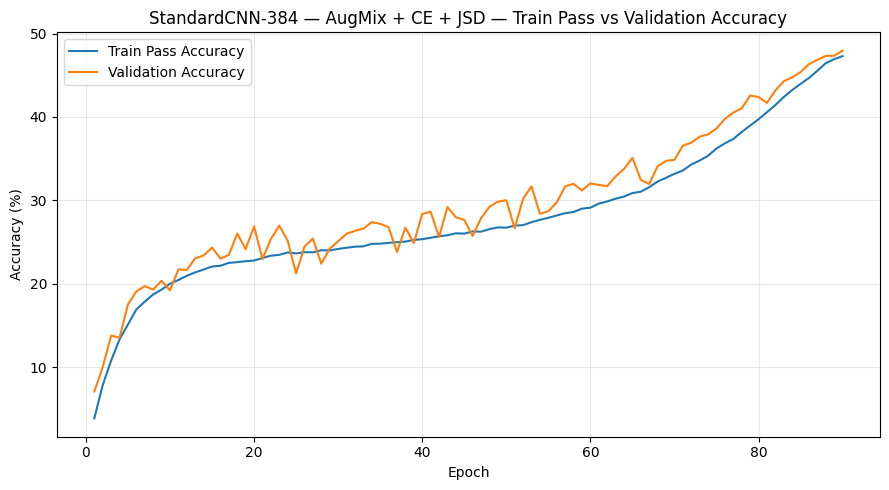

In [22]:
epochs_ran = range(1, len(history["train_accuracy"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["train_accuracy"], label="Train Pass Accuracy")
plt.plot(epochs_ran, history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("StandardCNN-384 — AugMix + CE + JSD — Train Pass vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 16. Training Pass and Validation Loss

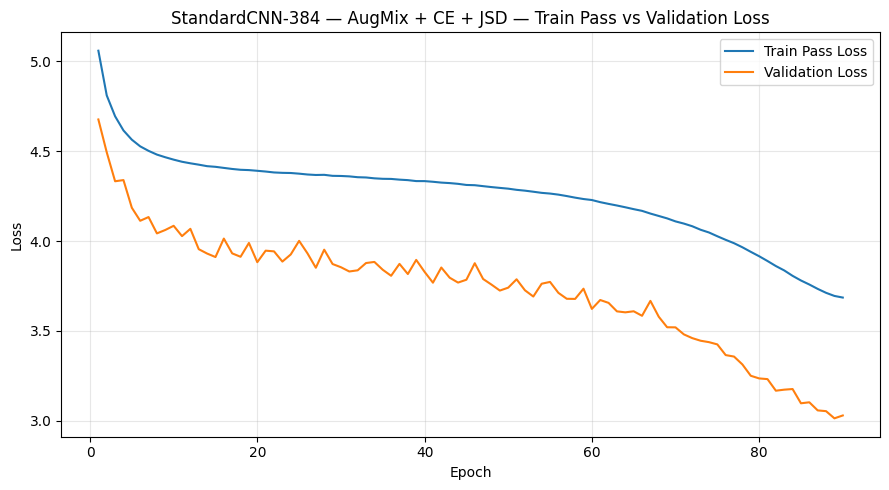

In [23]:
epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["train_loss"], label="Train Pass Loss")
plt.plot(epochs_ran, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("StandardCNN-384 — AugMix + CE + JSD — Train Pass vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 16B. CE and JSD Training Components

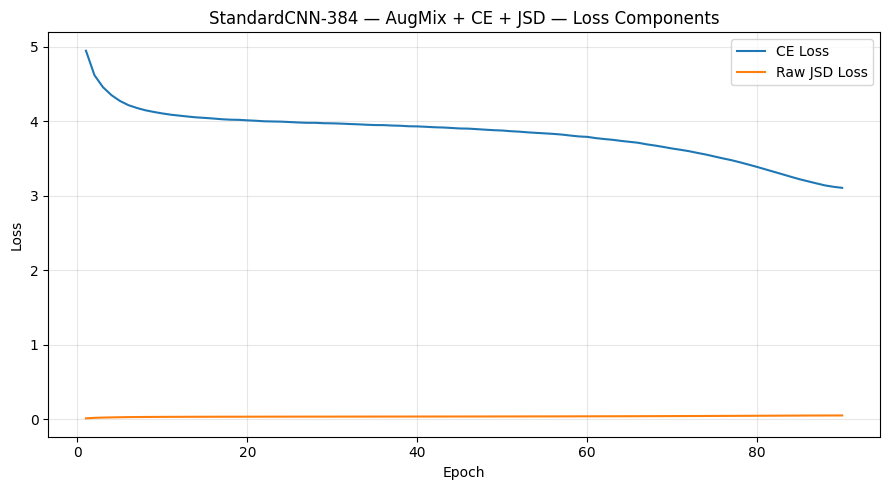

In [24]:
epochs_ran = range(1, len(history["train_ce_loss"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["train_ce_loss"], label="CE Loss")
plt.plot(epochs_ran, history["train_jsd_loss"], label="Raw JSD Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("StandardCNN-384 — AugMix + CE + JSD — Loss Components")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 17. Clean Train Evaluation vs Validation

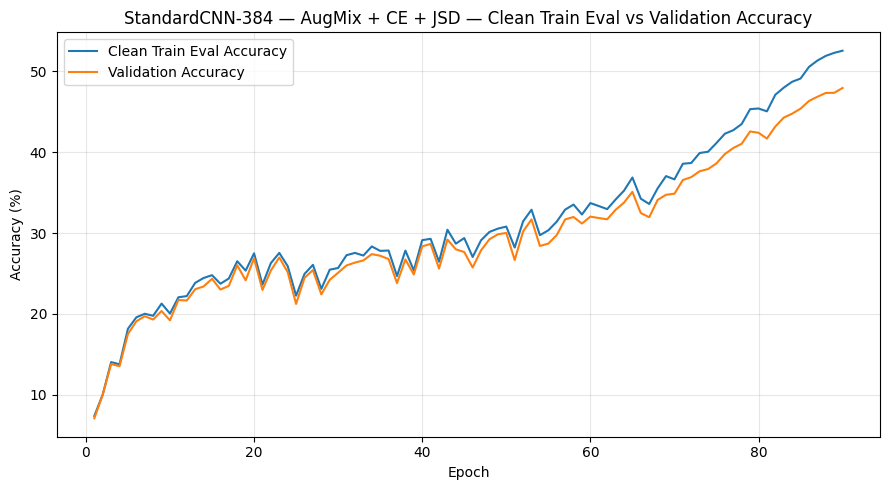

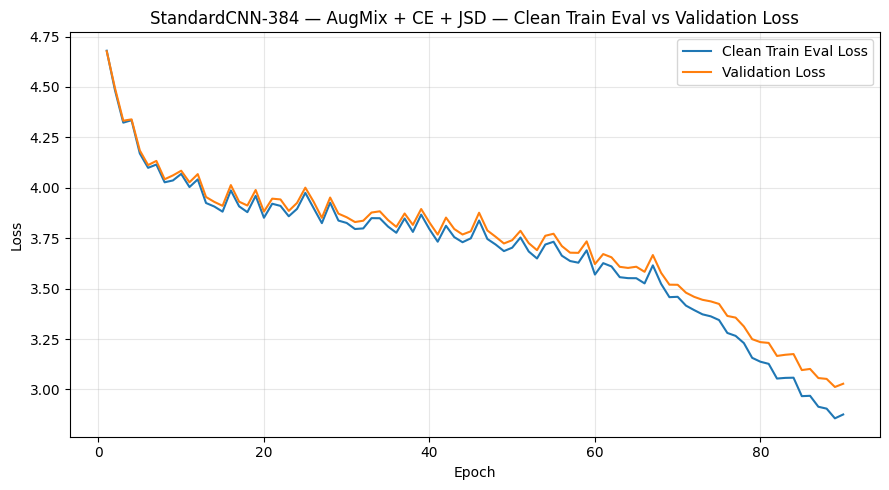

In [25]:
epochs_ran = range(1, len(history["train_eval_accuracy"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["train_eval_accuracy"], label="Clean Train Eval Accuracy")
plt.plot(epochs_ran, history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("StandardCNN-384 — AugMix + CE + JSD — Clean Train Eval vs Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["train_eval_loss"], label="Clean Train Eval Loss")
plt.plot(epochs_ran, history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("StandardCNN-384 — AugMix + CE + JSD — Clean Train Eval vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Generalization Gaps

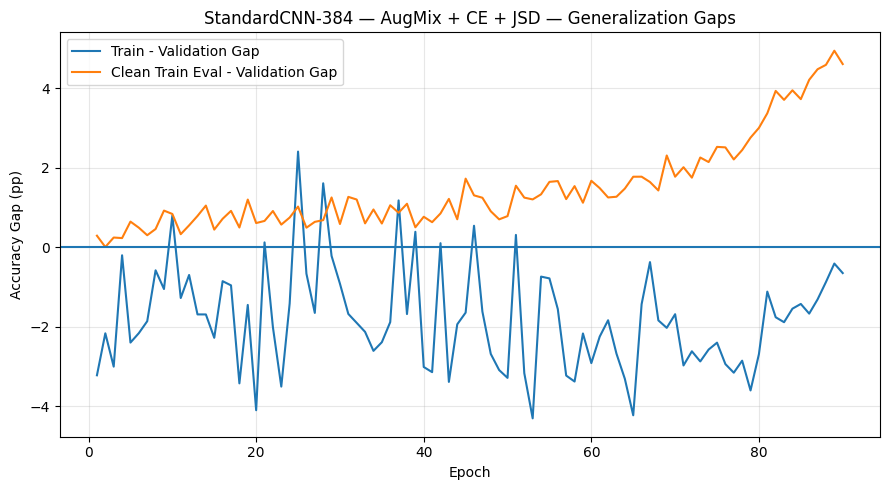

In [26]:
epochs_ran = range(1, len(history["train_val_gap"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["train_val_gap"], label="Train - Validation Gap")
plt.plot(epochs_ran, history["clean_train_eval_val_gap"], label="Clean Train Eval - Validation Gap")
plt.axhline(0)
plt.xlabel("Epoch")
plt.ylabel("Accuracy Gap (pp)")
plt.title("StandardCNN-384 — AugMix + CE + JSD — Generalization Gaps")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 19. OneCycleLR Curve

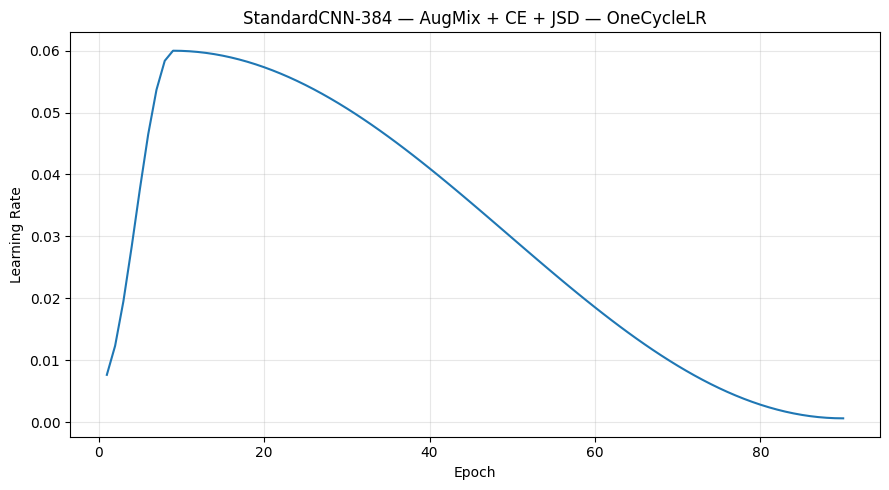

In [27]:
epochs_ran = range(1, len(history["learning_rate"]) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs_ran, history["learning_rate"])
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("StandardCNN-384 — AugMix + CE + JSD — OneCycleLR")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 20. Class-Wise Validation Accuracy

In [28]:
labels = best_val_result["labels"]
predictions = best_val_result["predictions"]

classwise_rows = []

for class_id in range(NUM_CLASSES):
    mask = labels == class_id
    total = mask.sum().item()
    correct = (predictions[mask] == class_id).sum().item()
    false = total - correct
    accuracy = 100.0 * correct / total if total > 0 else 0.0
    classwise_rows.append([class_id, CLASS_NAMES[class_id], total, correct, false, accuracy])

classwise_df = pd.DataFrame(classwise_rows,
                            columns=["Class", "Class Name", "Total", "Correct", "False", "Accuracy (%)"])
display(classwise_df)

,Class,Class Name,Total,Correct,False,Accuracy (%)
0,0,goldfish,50,42,8,84.0
1,1,European fire salamander,50,41,9,82.0
2,2,bullfrog,50,29,21,58.0
3,3,tailed frog,50,18,32,36.0
4,4,American alligator,50,29,21,58.0
...,...,...,...,...,...,...
195,195,cliff,50,24,26,48.0
196,196,coral reef,50,40,10,80.0
197,197,lakeside,50,14,36,28.0
198,198,seashore,50,32,18,64.0


## 21. Confusion Matrix — Plain Numeric Table

In [30]:
def confusion_matrix_from_tensors(labels, predictions, num_classes):
    matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    for true_label, predicted_label in zip(labels, predictions): matrix[int(true_label), int(predicted_label)] += 1
    return matrix


confusion_matrix = confusion_matrix_from_tensors(best_val_result["labels"], best_val_result["predictions"], NUM_CLASSES)
confusion_matrix_df = pd.DataFrame(confusion_matrix.numpy(), index=[f"True {i}" for i in range(NUM_CLASSES)],
                                   columns=[f"Pred {i}" for i in range(NUM_CLASSES)])

styled_confusion_matrix = confusion_matrix_df.style.set_properties(**{"font-size": "9px"}).set_table_styles([
    {"selector": "th", "props": [("font-size", "9px")]},
    {"selector": "td", "props": [("font-size", "9px")]}
])

print("Rows = True classes | Columns = Predicted classes")
display(styled_confusion_matrix)

Rows = True classes | Columns = Predicted classes
